In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


--- Loading Dataset: /content/drive/MyDrive/Trojan_Detection.csv ---
Features: 56 | Training Samples: 141985
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Naive Bayes...


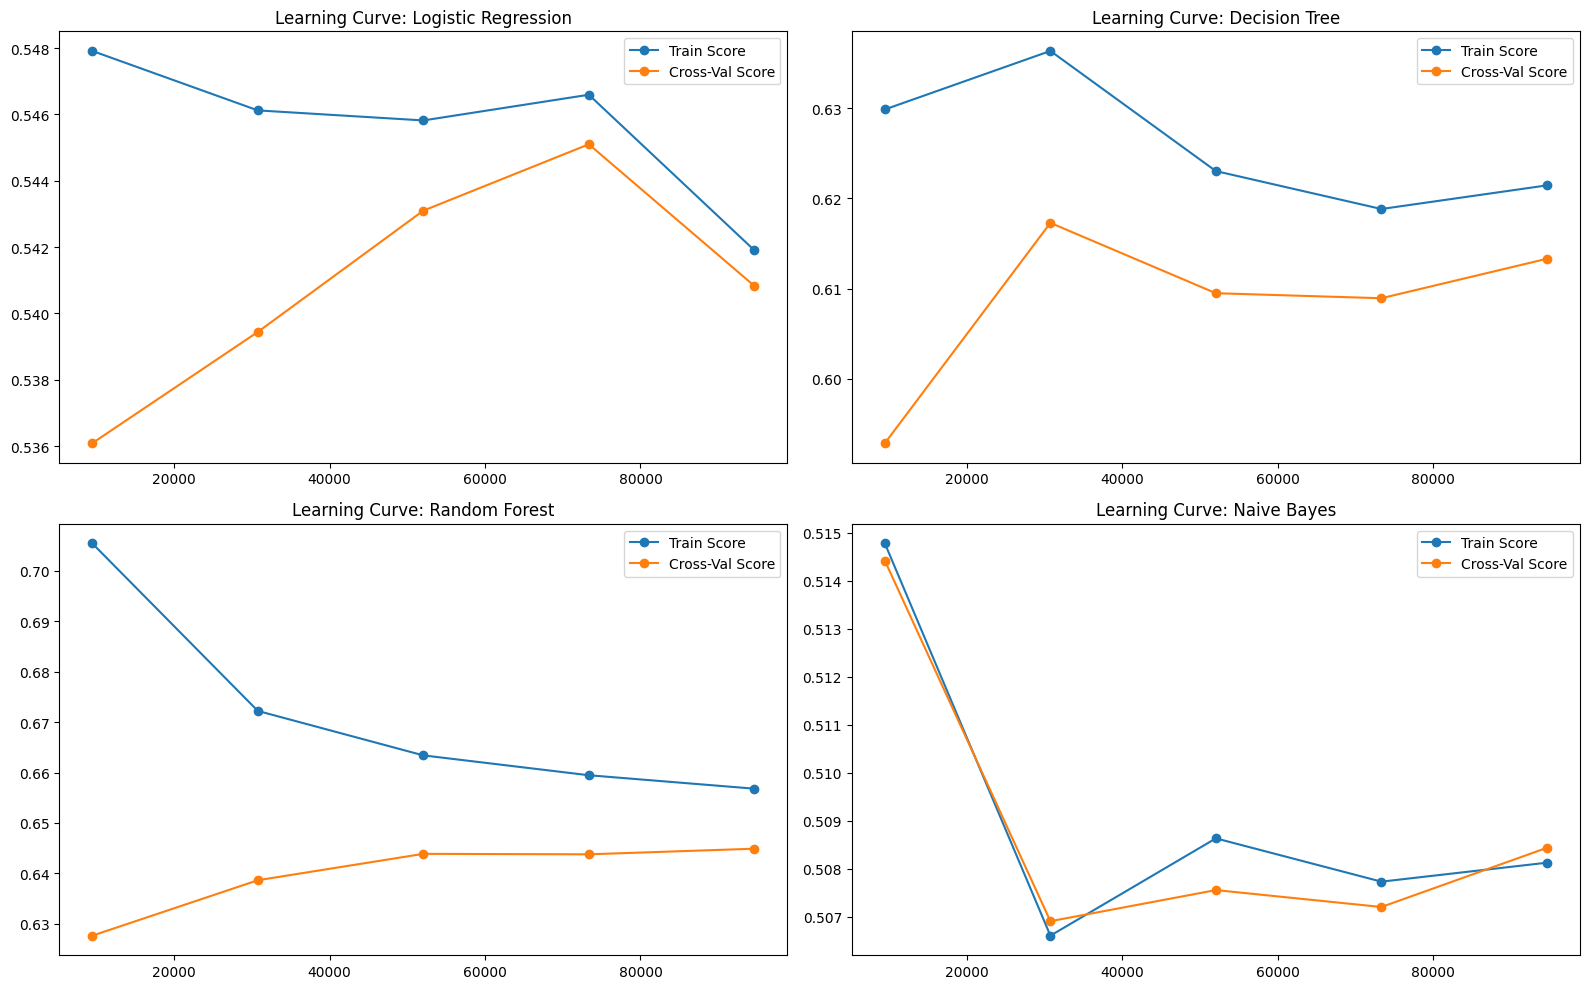


--- Training Deep Learning Models ---
Training Deep Learning MLP...
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5313 - loss: 0.6956 - val_accuracy: 0.5779 - val_loss: 0.6718
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5661 - loss: 0.6753 - val_accuracy: 0.5796 - val_loss: 0.6664
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5733 - loss: 0.6696 - val_accuracy: 0.5779 - val_loss: 0.6624
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5790 - loss: 0.6668 - val_accuracy: 0.5857 - val_loss: 0.6599
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5794 - loss: 0.6636 - val_accuracy: 0.5860 - val_loss: 0.6561
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5840 - loss: 0.6599 - val_accuracy: 0.5850 - val_loss: 0.6535
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5841 - loss: 0.6582 - val_accuracy: 0.5879 - val_loss: 0.6508
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━

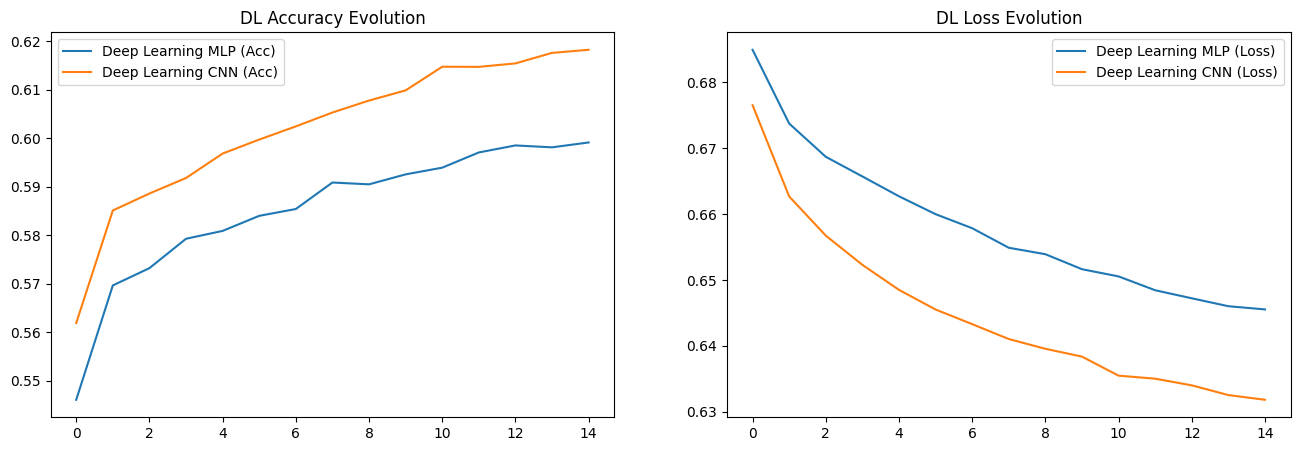

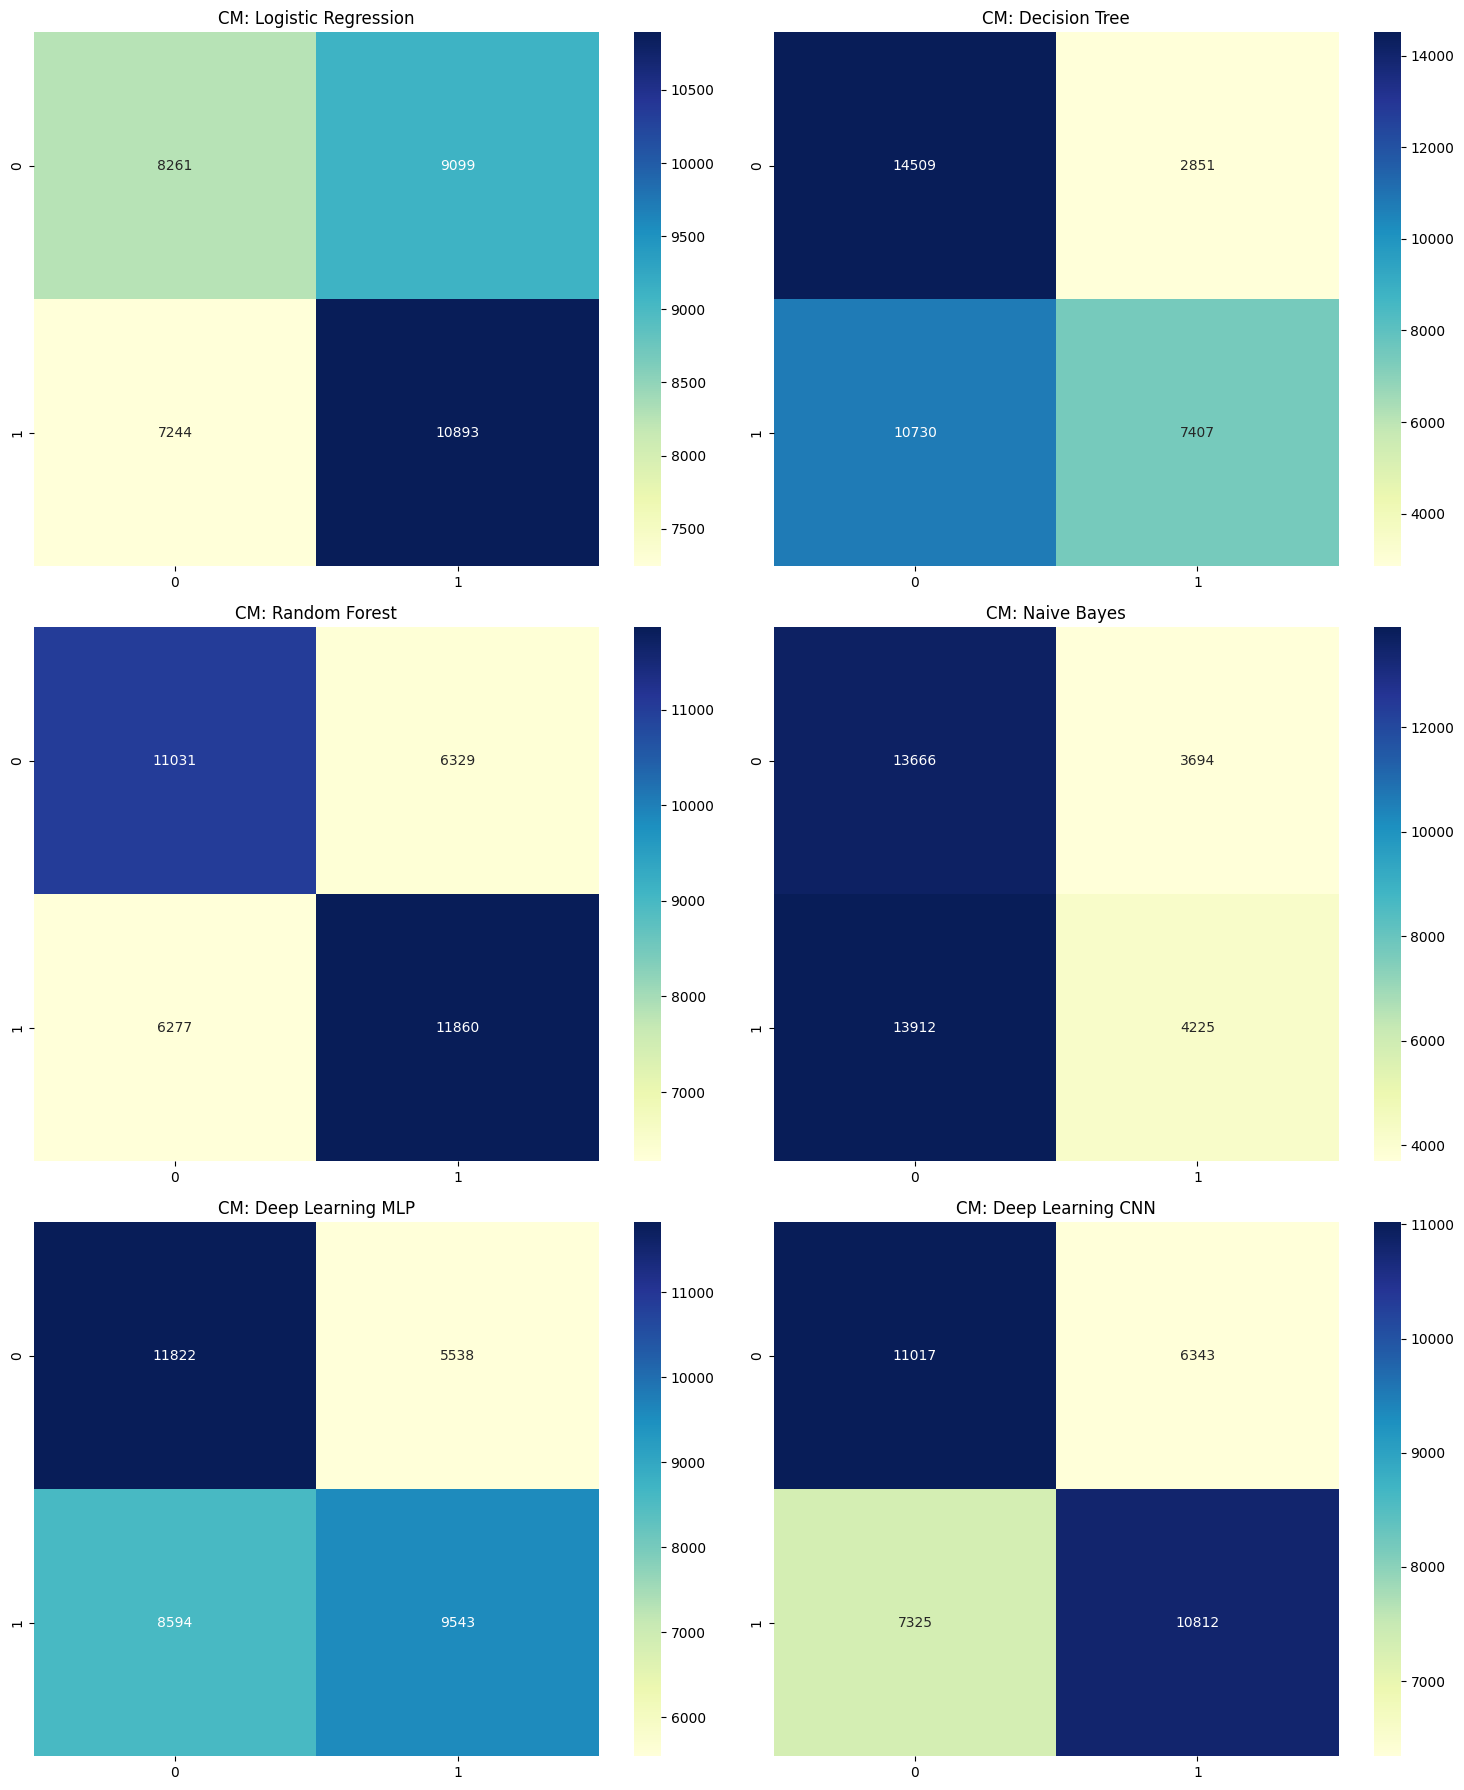

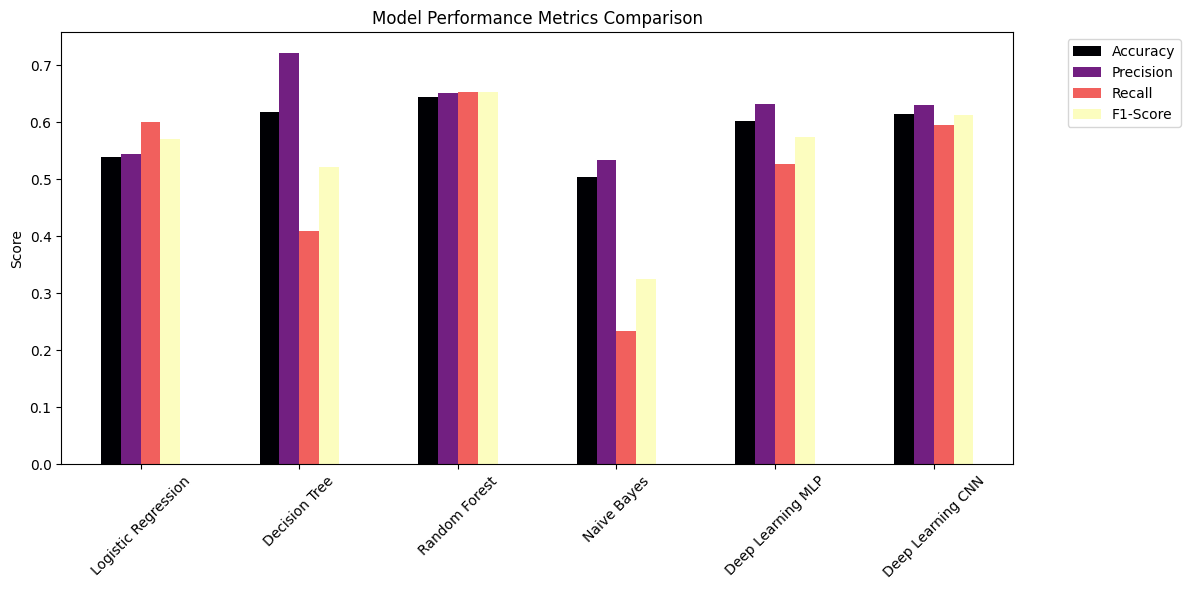


--- Final Metrics Summary ---
                     Accuracy Precision    Recall  F1-Score
Logistic Regression  0.539595  0.544868  0.600595  0.571376
Decision Tree        0.617404  0.722071  0.408392  0.521712
Random Forest        0.644871  0.652042  0.653912  0.652976
Naive Bayes          0.504014  0.533527  0.232949  0.324302
Deep Learning MLP    0.601882  0.632783  0.526162  0.574568
Deep Learning CNN    0.614953  0.630254  0.596129  0.612717


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, Flatten, MaxPooling1D
import warnings

warnings.filterwarnings('ignore')

# 1. DATA LOADING AND PREPROCESSING
dataset_path = "/content/drive/MyDrive/Trojan_Detection.csv"
print(f"--- Loading Dataset: {dataset_path} ---")

df = pd.read_csv(dataset_path)
df.columns = df.columns.str.strip()

# Dropping leakage columns
metadata_cols = ['Unnamed: 0', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp',
                 'Source Port', 'Destination Port', 'Protocol', 'Fwd Header Length.1']
df = df.drop(columns=[c for c in metadata_cols if c in df.columns], errors='ignore')

# Handle infinite and missing data
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

# Target Encoding
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
X = df.drop('Class', axis=1)
y = df['Class']

# Filter high correlation features (>95%)
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X = X.drop(columns=to_drop)

# Train-Test Split (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Features: {X.shape[1]} | Training Samples: {X_train_raw.shape[0]}")

# 2. ALGORITHMS IMPLEMENTATION
results = {}
dl_histories = {}

# --- 4 MACHINE LEARNING MODELS ---
ml_list = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=30),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1),
    "Naive Bayes": GaussianNB()
}

# Learning Curves for ML
fig_lc, axes_lc = plt.subplots(2, 2, figsize=(16, 10))
axes_lc = axes_lc.flatten()

for i, (name, model) in enumerate(ml_list.items()):
    print(f"Training {name}...")
    sizes, train_scores, test_scores = learning_curve(
        model, X_train_scaled, y_train, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
    )
    axes_lc[i].plot(sizes, np.mean(train_scores, axis=1), 'o-', label="Train Score")
    axes_lc[i].plot(sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-Val Score")
    axes_lc[i].set_title(f"Learning Curve: {name}"); axes_lc[i].legend()

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "cm": confusion_matrix(y_test, y_pred)
    }
plt.tight_layout(); plt.show()

# --- 2 DEEP LEARNING MODELS ---

# 1. Multi-Layer Perceptron (MLP)
def build_mlp(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 2. 1D Convolutional Neural Network (CNN)
def build_cnn(input_dim):
    model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(input_dim, 1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Prepare data for CNN (requires 3D input: samples, features, 1)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

dl_configs = {
    "Deep Learning MLP": (build_mlp(X_train_scaled.shape[1]), X_train_scaled, X_test_scaled),
    "Deep Learning CNN": (build_cnn(X_train_scaled.shape[1]), X_train_cnn, X_test_cnn)
}

print("\n--- Training Deep Learning Models ---")
for name, (model, train_data, test_data) in dl_configs.items():
    print(f"Training {name}...")
    history = model.fit(train_data, y_train, validation_split=0.1, epochs=15, batch_size=512, verbose=1)
    dl_histories[name] = history.history
    y_pred = (model.predict(test_data) > 0.5).astype(int)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "cm": confusion_matrix(y_test, y_pred)
    }

# 3. FINAL VISUALIZATIONS
# DL Training Curves
fig_dl, axes_dl = plt.subplots(1, 2, figsize=(16, 5))
for name, hist in dl_histories.items():
    axes_dl[0].plot(hist['accuracy'], label=f'{name} (Acc)'); axes_dl[1].plot(hist['loss'], label=f'{name} (Loss)')
axes_dl[0].set_title("DL Accuracy Evolution"); axes_dl[1].set_title("DL Loss Evolution")
axes_dl[0].legend(); axes_dl[1].legend(); plt.show()

# Confusion Matrices
fig_cm, axes_cm = plt.subplots(3, 2, figsize=(15, 18))
for i, (name, data) in enumerate(results.items()):
    sns.heatmap(data['cm'], annot=True, fmt='d', cmap='YlGnBu', ax=axes_cm.flatten()[i])
    axes_cm.flatten()[i].set_title(f"CM: {name}")
plt.tight_layout(); plt.show()

# Metrics Comparison Plot
metrics_df = pd.DataFrame(results).T.drop('cm', axis=1)
metrics_df.plot(kind='bar', figsize=(12, 6), colormap='magma')
plt.title("Model Performance Metrics Comparison"); plt.ylabel("Score"); plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left'); plt.tight_layout(); plt.show()

print("\n--- Final Metrics Summary ---")
print(metrics_df.round(4))